In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
import os
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [2]:
# Get the project root directory
from pathlib import Path
import sys

project_root = Path.cwd()
sys.path.append(str(project_root.parent))

from notebook_imports import *

In [3]:
# Set project directories using configuration
home_dir = str(config.PROJECT_ROOT)
data_dir = str(config.DATA_DIR)
resources_dir = str(config.RESOURCES_DIR)
results_dir = str(config.RESULTS_04_DIR)
figures_dir = str(config.FIGURES_04_DIR)

In [4]:
from compute_correlations import *

In [23]:
column_order = ['observations', 'CPA', 'GEARS', 'GEARS_noreg', 'scfoundation', 'no_effect', 'average_effect', 'importance']

color_palette = sns.color_palette([
    "#1f77b4",  # Model A - blue
    "#2ca02c",  # Model B Config 1 - green
    "#98df8a",  # Model B Config 2 - light green
    "#ff7f0e",  # Model C - orange
    "#7f7f7f",  # Baseline 1 - gray
    "#4d4d4d",  # Baseline 2 - dark gray
])

colors = {
    'Observations':'tab:red',
    'CPA': color_palette[0],
    'GEARS': color_palette[1],
    'GEARS\nOptimized': color_palette[2],
    'scFoundation': color_palette[3],
    'Average effect': color_palette[5],
    'No effect': color_palette[4]
}

In [6]:
sciplex_observations = get_observations()
sciplex_sensitivity = pd.read_csv(os.path.join(resources_dir, 'sciplex_sensitivity_info.csv'), index_col=0)

In [7]:

all_predictions = get_predictions()

Processing cell line: mcf7
Processing cell line: a549
Processing cell line: k562


In [8]:
sciplex_feature_importance = []

for i in range(0,5):
    split_feature_importance = pd.read_csv(os.path.join(results_dir, f'post_sciplex_regression_predictions_CV_twostep_AUC_{i}_twopart_feature_importance.csv'), index_col=0).T.assign(model='Post', condition='Full Sciplex dataset').assign(split=i).reset_index(drop=True)
    split_feature_importance_lfc = pd.read_csv(os.path.join(results_dir, f'lfc_sciplex_regression_predictions_CV_twostep_AUC_{i}_twopart_feature_importance.csv'), index_col=0).T.assign(model='Log(fold change)', condition='Full sciplex dataset').assign(split=i).reset_index(drop=True)
    sciplex_feature_importance.append(split_feature_importance)
    sciplex_feature_importance.append(split_feature_importance_lfc)
sciplex_feature_importance = pd.concat(sciplex_feature_importance, ignore_index=True)

sciplex_feature_importance = sciplex_feature_importance.drop(columns=['split']).groupby(['condition','model']).mean().reset_index()
sciplex_lfc_feature_importance = sciplex_feature_importance[sciplex_feature_importance['model'] == 'Log(fold change)']
sciplex_lfc_feature_importance = sciplex_lfc_feature_importance.drop(columns=['model', 'condition']).T.rename(columns={1: 'importance'}).reset_index().rename(columns={'index': 'gene'})

sciplex_post_feature_importance = sciplex_feature_importance[sciplex_feature_importance['model'] == 'Post']
sciplex_post_feature_importance = sciplex_post_feature_importance.drop(columns=['model', 'condition']).T.rename(columns={0: 'importance'}).reset_index().rename(columns={'index': 'gene'})

In [9]:
post_important_features = sciplex_post_feature_importance[abs(sciplex_post_feature_importance['importance'])>abs(sciplex_post_feature_importance['importance']).quantile(0.9)]['gene'].tolist()
post_important_feature_weights = sciplex_post_feature_importance[abs(sciplex_post_feature_importance['importance'])>abs(sciplex_post_feature_importance['importance']).quantile(0.9)]['importance'].tolist()

lfc_important_features = sciplex_lfc_feature_importance[abs(sciplex_lfc_feature_importance['importance'])>abs(sciplex_lfc_feature_importance['importance']).quantile(0.9)]['gene'].tolist()
lfc_important_feature_weights = sciplex_lfc_feature_importance[abs(sciplex_lfc_feature_importance['importance'])>abs(sciplex_lfc_feature_importance['importance']).quantile(0.9)]['importance'].tolist()

print(len(lfc_important_feature_weights))

100


In [10]:
sciplex_observations_subset = sciplex_observations[post_important_features + ['y', 'condition', 'cell_line']].copy()

In [12]:
corr_observations = compute_gene_gene_correlation(
    all_predictions['observations'],
    subset=sciplex_observations_subset.columns.tolist(),
    per_cell_line = False
)

corr_observations = corr_observations.reset_index()

corrs = {}

for m in all_predictions.keys():
    c = compute_gene_gene_correlation(
        all_predictions[m],
        subset=sciplex_observations_subset.columns.tolist(),
        per_cell_line= False
    )
    c = c.reset_index()

    corrs[m] = c

['observations',
 'CPA',
 'GEARS_noreg',
 'GEARS',
 'scfoundation',
 'no_effect',
 'average_effect']

c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


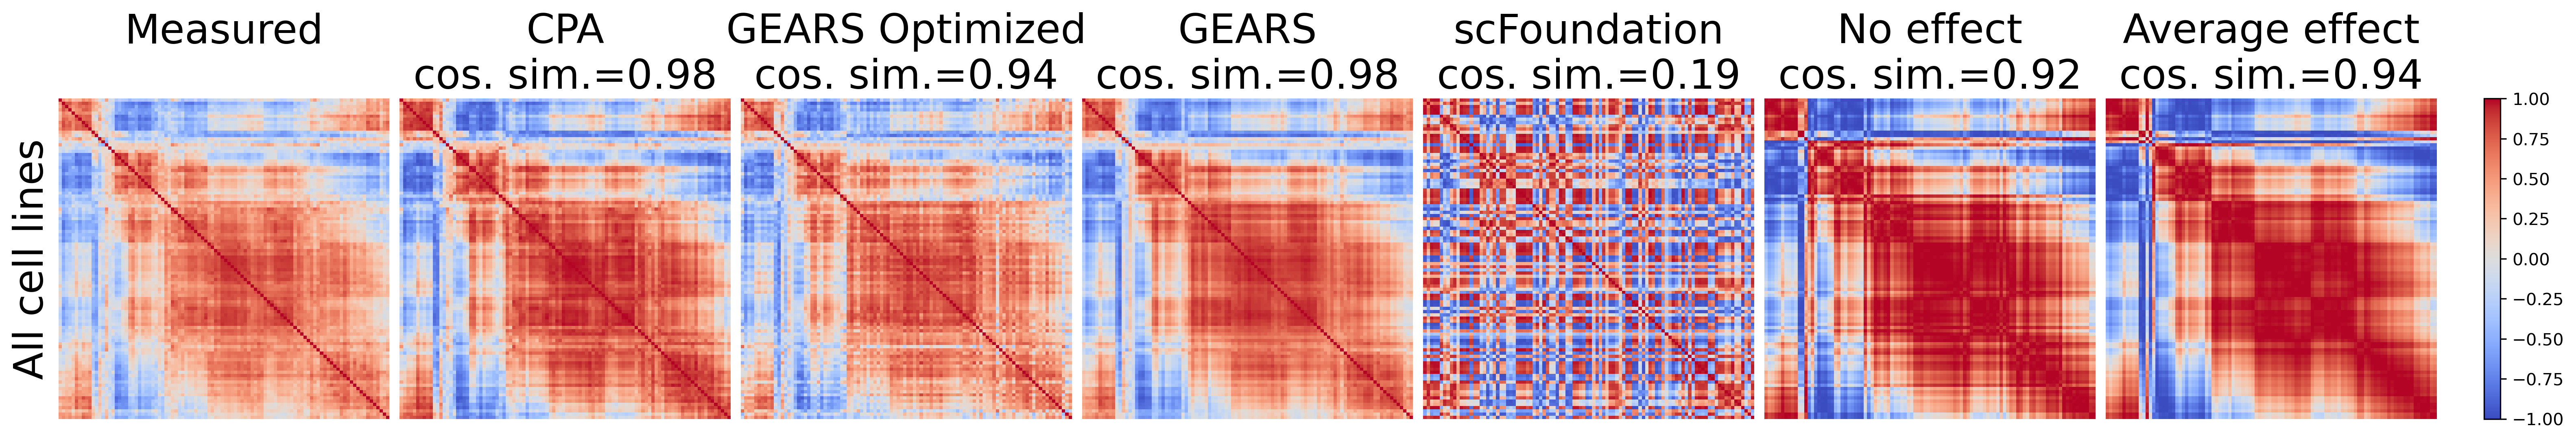

In [16]:
fig, axes = plt.subplots(
    1, 7, figsize=(21, 3.5), constrained_layout=True, dpi=300)

corr_observations_cl = corr_observations.set_index(corr_observations.iloc[:, 0]).drop(columns=corr_observations.columns[0])

g = sns.clustermap(
    corr_observations_cl,
    cmap='coolwarm', center=0, vmin=-1, vmax=1, figsize=(8, 8), row_cluster=True, col_cluster=True)
plt.close(g.fig)

row_order = [corr_observations_cl.index[i] for i in g.dendrogram_row.reordered_ind]
col_order = [corr_observations_cl.columns[i] for i in g.dendrogram_col.reordered_ind]

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

cos_sims = {}
obs_vec = corr_observations_cl.values.flatten()

def upper_tri_vector(M):
    """Return the upper-triangular (k=1) vector of a square matrix M."""
    iu = np.triu_indices_from(M, k=1)
    return M.values[iu]
    # return M.values.flatten()

def safe_pair(a, b):
    """Mask NaNs to align valid positions in both vectors."""
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask], b[mask]

obs_vec = upper_tri_vector(corr_observations_cl)

rows = []
for j, m in enumerate(list(['observations'] + [k for k in corrs.keys() if k != 'observations'])):
    # if m == 'observations':
    #     continue
    mod_corrs = corrs[m].copy()
    mod_corrs = mod_corrs.set_index(mod_corrs.iloc[:, 0]).drop(columns=mod_corrs.columns[0])
    modd_corrs = mod_corrs.loc[row_order, col_order]
    mod_vec = upper_tri_vector(mod_corrs)
    a, b = safe_pair(obs_vec, mod_vec)
    if a.size == 0:
        rows.append({
            'model': m, 'pearson': np.nan, 'spearman': np.nan, 'cosine': np.nan,
            'rmse': np.nan, 'mae': np.nan, 'mean_abs_diff': np.nan, 'max_abs_diff': np.nan,
            'ssim': np.nan
        })
        continue

    cos_sims[m] = float(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0, 0])
    ax = axes[j]
    sns.heatmap(
        modd_corrs,
        ax=ax,
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        xticklabels=False, yticklabels=False,
        cbar=False
    )
    title_map = {'GEARS_noreg': 'GEARS Optimized','scfoundation':'scFoundation','average_effect':'Average effect', 'no_effect':'No effect', 'observations':'Measured\n '}
    t = title_map.get(m, m)

    # Add cosine similarity in title, except for observed itself
    cos_val = cos_sims.get(m, np.nan)
    title_map = {'observations': 'observations',
                    }
    if m == 'observations':
        title = f"{t}"
    else:
        title = f"{t}\ncos. sim.={cos_val:.2f}" if np.isfinite(cos_val) else f"{m}\ncos. sim.=NA"

    ax.set_title(title, fontsize=24)
    if j == 0:
        ax.set_ylabel('All cell lines', fontsize=24)
    else:
        ax.set_ylabel('')
    ax.set_xlabel('')

# # 4) Add one colorbar per row (right-most subplot of each row)
# # Top row colorbar (correlations)
cb_top = fig.colorbar(
    axes[-1].collections[0],
    ax=axes[:].ravel().tolist(),
    fraction=0.03, pad=0.02
)
cb_top.set_label("", rotation=270, labelpad=16, fontsize=20)

plt.show()

fig.savefig(os.path.join(figures_dir, 'gene_gene_correlations.pdf'), bbox_inches='tight', dpi=300)


In [17]:
corr_observations = compute_gene_gene_correlation(
    all_predictions['observations'],
    subset=sciplex_observations_subset.columns.tolist(),
    per_cell_line = True
)

corr_observations = corr_observations.reset_index()

corrs = {}

for m in all_predictions.keys():
    c = compute_gene_gene_correlation(
        all_predictions[m],
        subset=sciplex_observations_subset.columns.tolist(),
        per_cell_line = True
    )
    c = c.reset_index()

    corrs[m] = c


c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py

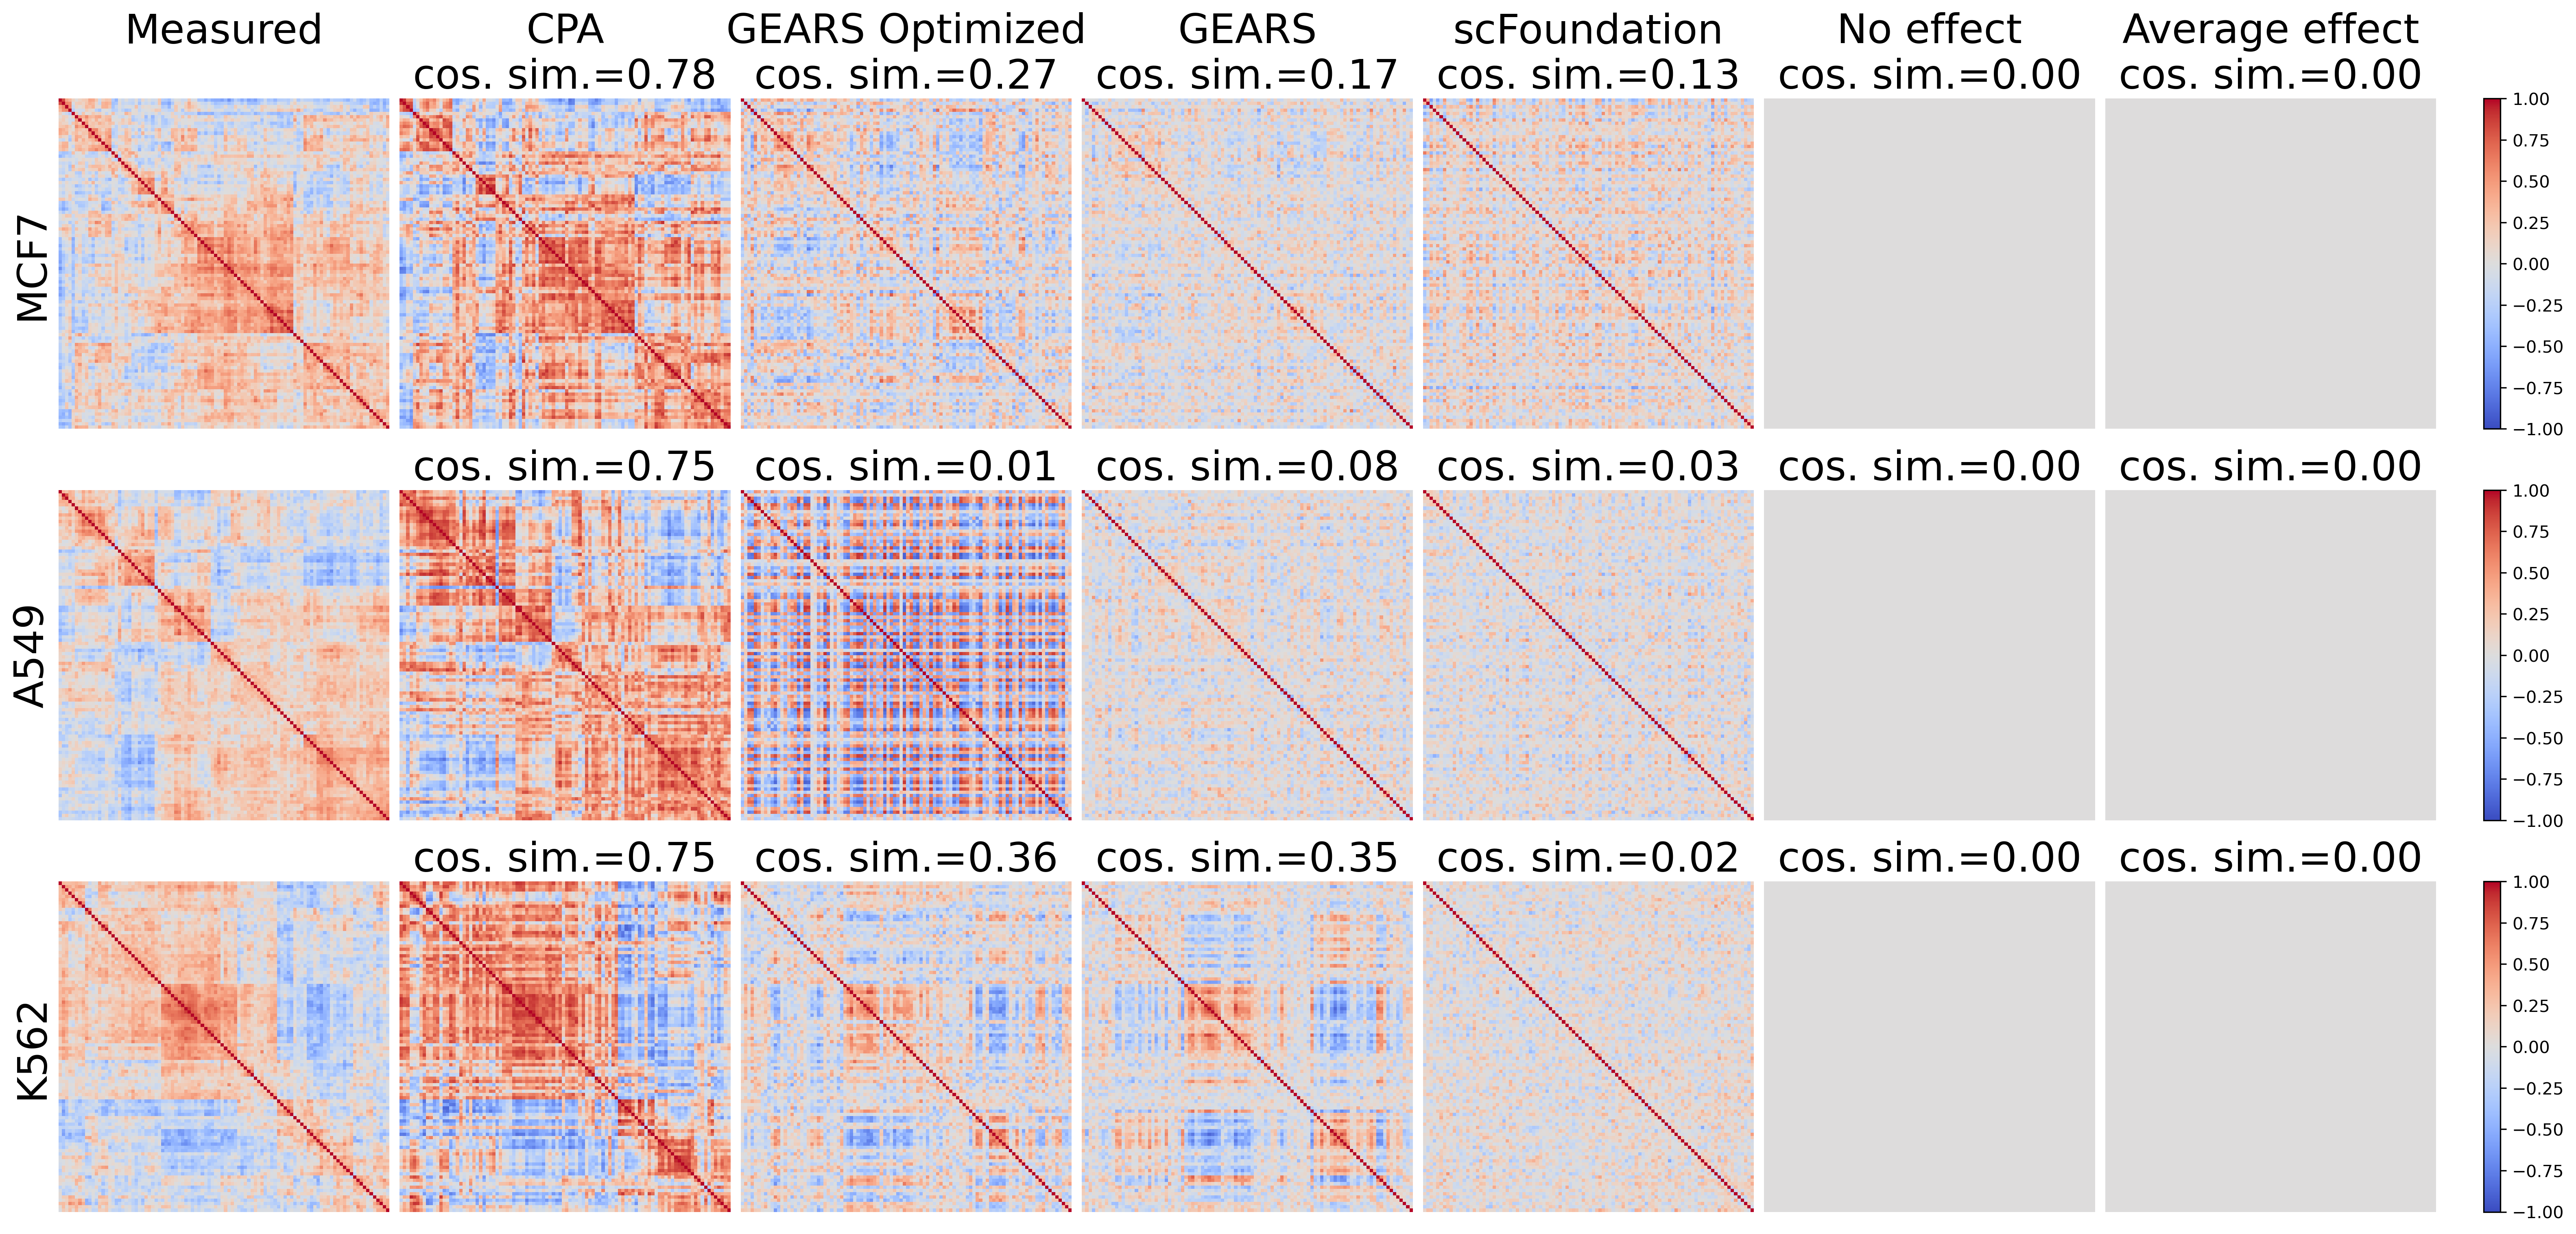

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update(plt.rcParamsDefault)


fig, axes = plt.subplots(
    3, 7, figsize=(21, 10), constrained_layout=True, dpi=300)


for row, cl in enumerate(['MCF7', 'A549', 'K562']):
    corr_observations_cl = corr_observations[corr_observations['level_0'] == cl].drop(columns=['level_0'])
    corr_observations_cl = corr_observations_cl.set_index(corr_observations_cl.iloc[:, 0]).drop(columns=corr_observations_cl.columns[0])
    
    g = sns.clustermap(
        corr_observations_cl,
        cmap='vlag', center=0, vmin=-1, vmax=1, figsize=(8, 8), row_cluster=True, col_cluster=True)
    plt.close(g.fig)

    row_order = [corr_observations_cl.index[i] for i in g.dendrogram_row.reordered_ind]
    col_order = [corr_observations_cl.columns[i] for i in g.dendrogram_col.reordered_ind]

    cos_sims = {}
    obs_vec = corr_observations_cl.values.flatten()

    def upper_tri_vector(M):
        """Return the upper-triangular (k=1) vector of a square matrix M."""
        iu = np.triu_indices_from(M, k=1)
        return M.values[iu]
        # return M.values.flatten()

    def safe_pair(a, b):
        """Mask NaNs to align valid positions in both vectors."""
        mask = np.isfinite(a) & np.isfinite(b)
        return a[mask], b[mask]

    obs_vec = upper_tri_vector(corr_observations_cl)

    rows = []
    for j, m in enumerate(list(['observations'] + [k for k in corrs.keys() if k != 'observations'])):
        # if m == 'observations':
        #     continue
        mod_corrs = corrs[m].copy()
        mod_corrs = mod_corrs[mod_corrs['level_0'] == cl].drop(columns=['level_0'])
        mod_corrs = mod_corrs.set_index(mod_corrs.iloc[:, 0]).drop(columns=mod_corrs.columns[0])
        modd_corrs = mod_corrs.loc[row_order, col_order]
        mod_vec = upper_tri_vector(mod_corrs)
        a, b = safe_pair(obs_vec, mod_vec)
        if a.size == 0:
            rows.append({
                'model': m, 'pearson': np.nan, 'spearman': np.nan, 'cosine': np.nan,
                'rmse': np.nan, 'mae': np.nan, 'mean_abs_diff': np.nan, 'max_abs_diff': np.nan,
                'ssim': np.nan
            })
            continue

        cos_sims[m] = float(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0, 0])
        ax = axes[row, j]
        sns.heatmap(
            modd_corrs,
            ax=ax,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar=False
        )
        title_map = {'GEARS_noreg': 'GEARS Optimized','scfoundation':'scFoundation','average_effect':'Average effect', 'no_effect':'No effect', 'observations':'Measured\n '}
        t = title_map.get(m, m)

        # Add cosine similarity in title, except for observed itself
        cos_val = cos_sims.get(m, np.nan)
        if row == 0:
            if m == 'observations':
                title = t
            else:
                title = t + f"\ncos. sim.={cos_val:.2f}" if np.isfinite(cos_val) else f"{m}\ncos. sim.=NA"
        else:
            if m == 'observations':
                title = ""
            else:
                title = f"cos. sim.={cos_val:.2f}" if np.isfinite(cos_val) else f"{m}\ncos. sim.=NA"
        ax.set_title(title, fontsize=24)
        if j == 0:
            ax.set_ylabel(cl, fontsize=24)
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')

# # 4) Add one colorbar per row (right-most subplot of each row)
# # Top row colorbar (correlations)
cb_top = fig.colorbar(
    axes[0, -1].collections[0],
    ax=axes[0, :].ravel().tolist(),
    fraction=0.03, pad=0.02
)
cb_top.set_label("", rotation=270, labelpad=16, fontsize=20)

cb_mid = fig.colorbar(
    axes[1, -1].collections[0],
    ax=axes[1, :].ravel().tolist(),
    fraction=0.03, pad=0.02
)
cb_mid.set_label("", rotation=270, labelpad=16, fontsize=20)

cb_bottom = fig.colorbar(
    axes[2, -1].collections[0],
    ax=axes[2, :].ravel().tolist(),
    fraction=0.03, pad=0.02
)
cb_bottom.set_label("", rotation=270, labelpad=16, fontsize=20)
# Row labels

plt.show()

fig.savefig(os.path.join(figures_dir, 'gene_gene_correlations_per_cell_line.pdf'), bbox_inches='tight', dpi=300)


c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\nbrouwer1\AppData\Local\anaconda3\envs\notebook_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


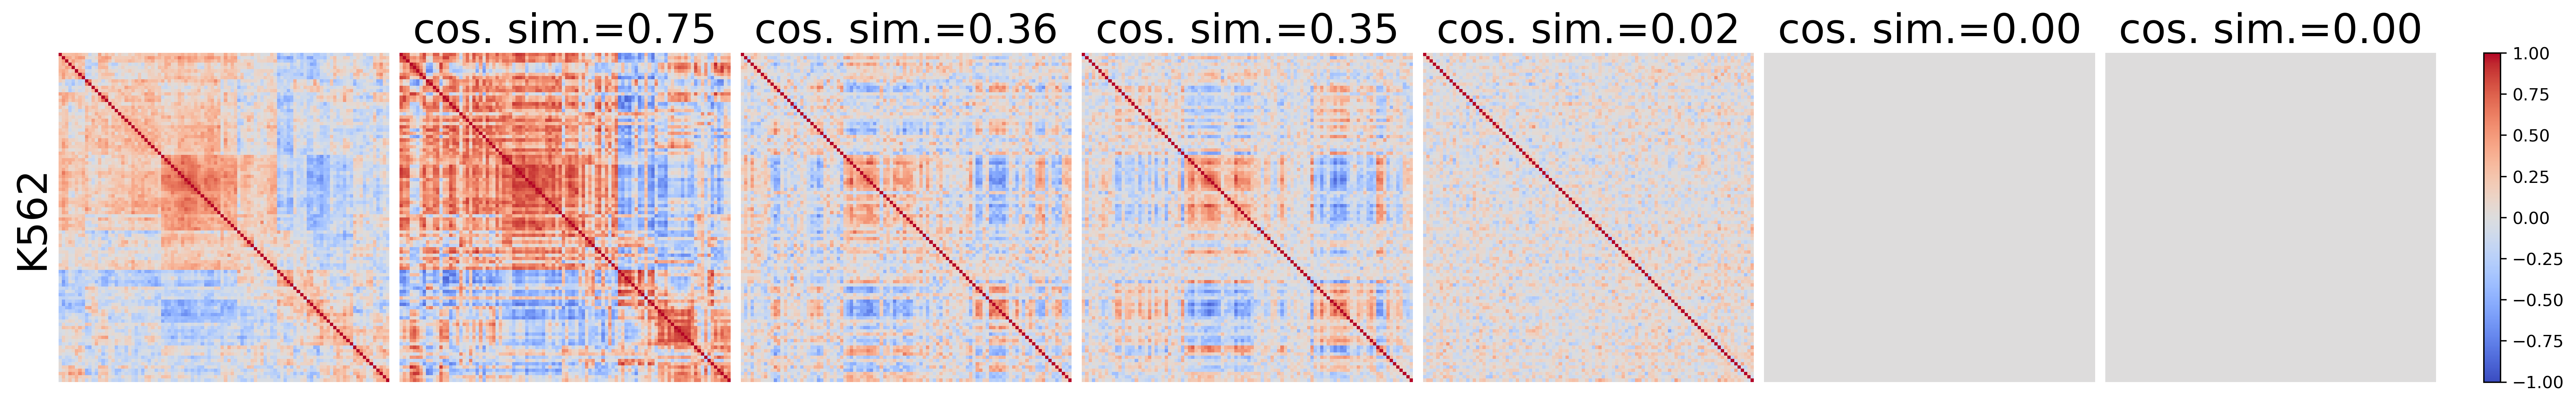

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    1, 7, figsize=(21, 3.2), constrained_layout=True, dpi=300)


for row, cl in enumerate(['K562']):
    corr_observations_cl = corr_observations[corr_observations['level_0'] == cl].drop(columns=['level_0'])
    corr_observations_cl = corr_observations_cl.set_index(corr_observations_cl.iloc[:, 0]).drop(columns=corr_observations_cl.columns[0])
    
    g = sns.clustermap(
        corr_observations_cl,
        cmap='coolwarm', center=0, vmin=-1, vmax=1, figsize=(8, 8), row_cluster=True, col_cluster=True)
    plt.close(g.fig)

    row_order = [corr_observations_cl.index[i] for i in g.dendrogram_row.reordered_ind]
    col_order = [corr_observations_cl.columns[i] for i in g.dendrogram_col.reordered_ind]

    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np

    cos_sims = {}
    obs_vec = corr_observations_cl.values.flatten()

    def upper_tri_vector(M):
        """Return the upper-triangular (k=1) vector of a square matrix M."""
        iu = np.triu_indices_from(M, k=1)
        return M.values[iu]
        # return M.values.flatten()

    def safe_pair(a, b):
        """Mask NaNs to align valid positions in both vectors."""
        mask = np.isfinite(a) & np.isfinite(b)
        return a[mask], b[mask]

    obs_vec = upper_tri_vector(corr_observations_cl)

    rows = []
    for j, m in enumerate(list(['observations'] + [k for k in corrs.keys() if k != 'observations'])):
        # if m == 'observations':
        #     continue
        mod_corrs = corrs[m].copy()
        mod_corrs = mod_corrs[mod_corrs['level_0'] == cl].drop(columns=['level_0'])
        mod_corrs = mod_corrs.set_index(mod_corrs.iloc[:, 0]).drop(columns=mod_corrs.columns[0])
        modd_corrs = mod_corrs.loc[row_order, col_order]
        mod_vec = upper_tri_vector(mod_corrs)
        a, b = safe_pair(obs_vec, mod_vec)
        if a.size == 0:
            rows.append({
                'model': m, 'pearson': np.nan, 'spearman': np.nan, 'cosine': np.nan,
                'rmse': np.nan, 'mae': np.nan, 'mean_abs_diff': np.nan, 'max_abs_diff': np.nan,
                'ssim': np.nan
            })
            continue

        cos_sims[m] = float(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0, 0])
        ax = axes[j]
        sns.heatmap(
            modd_corrs,
            ax=ax,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar=False
        )
        title_map = {'GEARS_noreg': 'GEARS Optimized','GEARS_scfoundation':'scFoundation', 'baseline':'Average effect', 'identity':'No effect', 'observations':'Measured\n '}
        t = title_map.get(m, m)

        # Add cosine similarity in title, except for observed itself
        cos_val = cos_sims.get(m, np.nan)
        title_map = {'observations': 'observations',
                     }
        if m == 'observations':
            title = f""
        else:
            title = f"cos. sim.={cos_val:.2f}" if np.isfinite(cos_val) else f"{m}\ncos. sim.=NA"
        ax.set_title(title, fontsize=24)
        if j == 0:
            ax.set_ylabel(cl, fontsize=24)
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')

# # 4) Add one colorbar per row (right-most subplot of each row)
# # Top row colorbar (correlations)
cb_top = fig.colorbar(
    axes[-1].collections[0],
    ax=axes[:].ravel().tolist(),
    fraction=0.03, pad=0.02
)
cb_top.set_label("", rotation=270, labelpad=16, fontsize=20)

plt.show()

fig.savefig(os.path.join(figures_dir, 'gene_gene_correlations_k562.pdf'), bbox_inches='tight', dpi=300)


In [20]:
results = {}

for model, predictions in all_predictions.items():
    print(model)
    results[model] = compute_correlation_with_y(predictions, subset = sciplex_observations_subset.columns.tolist())
    
results = pd.DataFrame(results)

results_mse = {}

for model, predictions in all_predictions.items():
    print(model)
    results_mse[model] = compute_mse_per_gene(predictions, subset = sciplex_observations_subset.columns.tolist())
    
results_mse = pd.DataFrame(results_mse)

CPA
GEARS_noreg
GEARS
scfoundation
no_effect
average_effect
observations
CPA
GEARS_noreg
GEARS
scfoundation
no_effect
average_effect
observations


In [25]:
results_with_fi = pd.merge(results.reset_index(), sciplex_post_feature_importance, left_on='index', right_on='gene', how='left').drop(columns=['index'])
results_with_fi = results_with_fi.set_index('gene')
results_with_fi = results_with_fi[column_order]
results_with_fi.rename(columns={'GEARS_noreg': 'GEARS\nOptimized','scfoundation':'scFoundation', 'no_effect':'No effect', 'average_effect':'Average effect', 'observations':'Observations'}, inplace=True)

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_11816\2460622048.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_11816\2460622048.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col_cmap = cm.get_cmap("Reds")


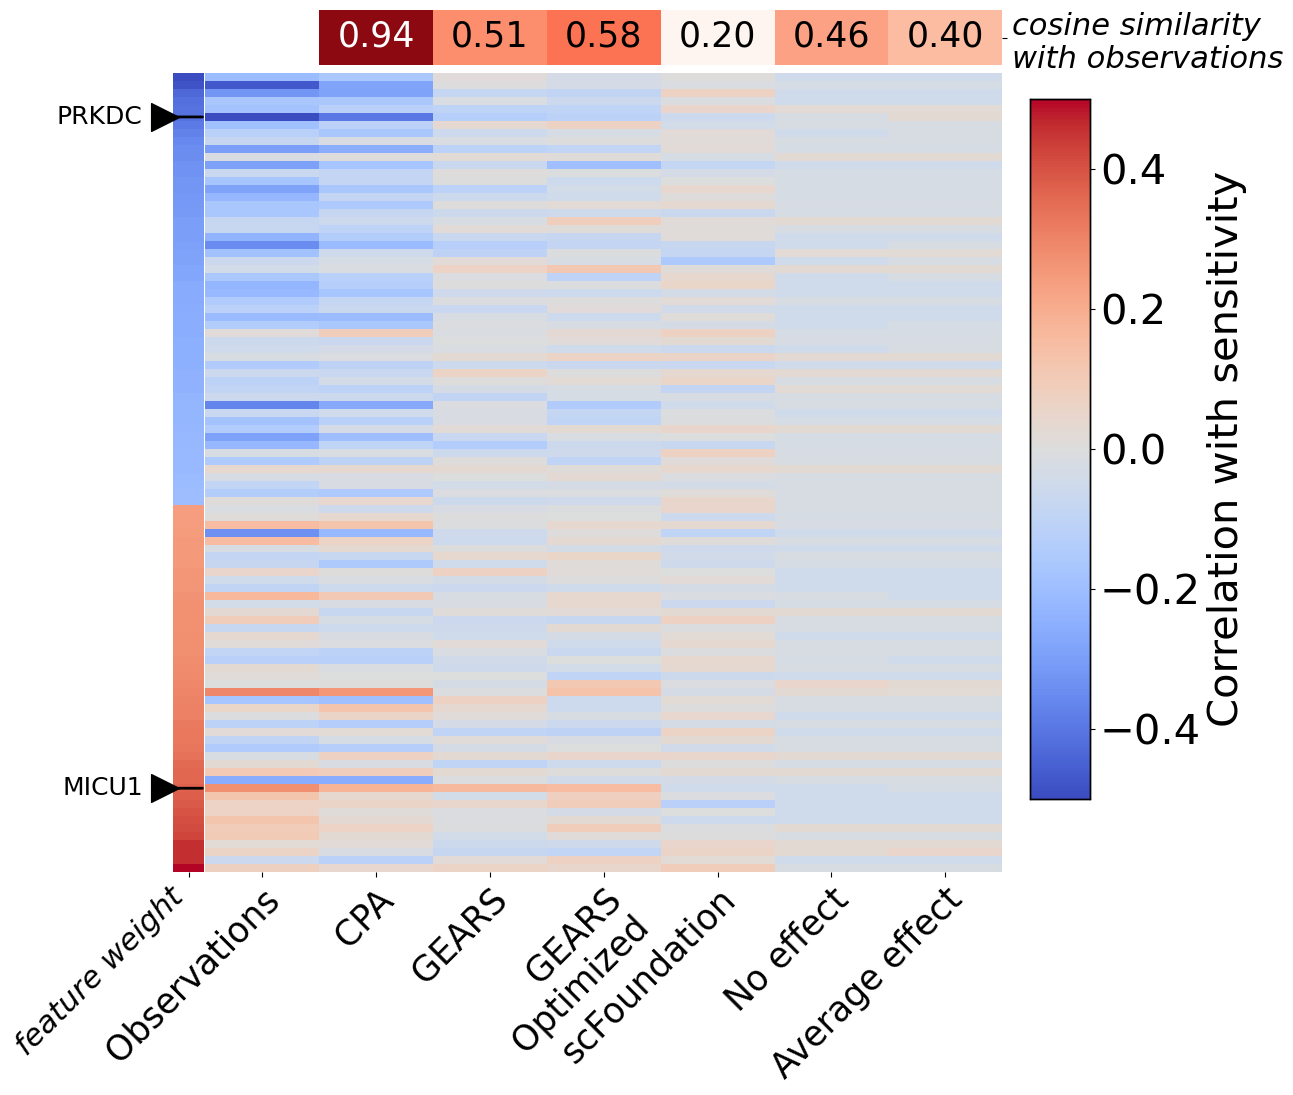

In [27]:
mpl.rcParams.update({
    "pdf.fonttype": 3,   # convert text to paths
    "ps.fonttype": 3,
})

# --- Row annotation (importance) ---
norm = mcolors.Normalize(vmin=results_with_fi['importance'].min(),
                          vmax=results_with_fi['importance'].max())
cmap = cm.get_cmap('coolwarm')

column_values = results_with_fi.sort_values(by='importance')['importance'].copy()
column_colors = column_values.map(lambda x: cmap(norm(x)))
row_annotation = pd.DataFrame({'feature weight': column_colors}, index=column_values.index)

# --- Heatmap data ---
heatmap_df = results_with_fi.sort_values(by='importance').drop(columns=['importance'])

# --- Cosine similarity for columns ---
target_vector = heatmap_df['Observations'].values.reshape(-1, 1).T
similarities = cosine_similarity(heatmap_df.T, target_vector).flatten()
cosine_sim_series = pd.Series(similarities, index=heatmap_df.columns)

# --- Column annotation (cosine similarity colors) ---
col_norm = mcolors.Normalize(vmin=cosine_sim_series.min(),
                              vmax=cosine_sim_series.max())
col_cmap = cm.get_cmap("Reds")

# map similarities to RGBA colors
col_colors = cosine_sim_series.map(lambda x: col_cmap(col_norm(x)))
col_colors.iloc[0] = (1, 1, 1, 1)  # RGBA white

# IMPORTANT: reorder to match heatmap_df.columns
column_annotation = pd.DataFrame({'cosine similarity\nwith observations': col_colors},
                                 index=heatmap_df.columns)

# --- Clustermap ---
g = sns.clustermap(
    heatmap_df,
    cmap='coolwarm',
    center=0,
    vmax=0.5,
    vmin=-0.5,
    method='average',
    row_cluster=False,
    col_cluster=False,
    row_colors=row_annotation,
    col_colors=column_annotation,
    yticklabels=False,
    xticklabels=True,
    figsize=(12, 10)
)

# --- Cosine similarity numbers on top (your code) ---
xticks = np.arange(len(heatmap_df.columns)) + 0.5  # center of each column
ytop = len(heatmap_df) - 105  # just above the heatmap

for x, col in enumerate(heatmap_df.columns):
    value = cosine_sim_series[col]
    text_color = 'white' if x < 2 else 'black'
    g.ax_heatmap.text(
        x + 0.5, ytop + 2.5,
        f"{value:.2f}",
        ha='center', va='bottom',
        fontsize=25, rotation=0, color=text_color
    )

# --- POINTERS TO SPECIFIC ROWS ------------------------------------------------
# Edit these three labels to the rows you want to mark
rows_to_point = ['PRKDC','MICU1']

# Map row labels to y positions (row_cluster=False => display order == heatmap_df.index)
row_to_y = {}
for r in rows_to_point:
    idx = heatmap_df.index.get_indexer([r])[0]
    if idx == -1:
        print(f"[warn] Row not found in heatmap_df.index: {r}")
    else:
        row_to_y[r] = idx + 0.5  # center of the row cell

# Pointer placement controls
x_pointer = -0.35      # how far left the pointer appears
label_offset = 0.2    # space between label text and pointer tail

for r, y in row_to_y.items():
    # Right-pointing triangle as a pointer head
    g.ax_heatmap.scatter([x_pointer], [y], marker=">", s=400, color="black",
                         clip_on=False, zorder=5)

    # Short shaft from pointer towards the first column
    g.ax_heatmap.annotate(
        "", xy=(0.0, y), xytext=(x_pointer + 0.05, y),
        xycoords=("data", "data"), textcoords=("data", "data"),
        arrowprops=dict(arrowstyle="-", lw=2, color="black"),
        clip_on=False, zorder=4,
    )

    # Optional label next to the pointer
    g.ax_heatmap.text(
        x_pointer - label_offset, y, r,
        ha="right", va="center", fontsize=18,
        clip_on=False, zorder=6
    )
# -----------------------------------------------------------------------------

# --- Styling (your code) ---
for label in g.ax_col_colors.get_yticklabels():
    label.set_fontsize(22)  # column annotation labels
    label.set_fontstyle('italic')

for label in g.ax_row_colors.get_xticklabels():
    label.set_fontsize(22)  # row annotation labels
    label.set_fontstyle('italic')
    label.set_rotation(45)
    label.set_ha('right')

g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('', fontdict={'fontsize': 30}, labelpad=150)
g.ax_heatmap.yaxis.set_label_position("left")

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=25)
g.cax.set_visible(True)
g.cax.set_position([0.9, 0.2, 0.05, 0.7])  # [x, y, width, height]
g.cax.tick_params(labelsize=30)
g.cax.set_ylabel('Correlation with sensitivity', fontsize=30)

plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)

# Remove the empty dendrogram axis to shrink whitespace
if hasattr(g, "ax_col_dendrogram"):
    g.ax_col_dendrogram.set_visible(False)
    g.ax_row_dendrogram.set_visible(False)

# Make the row dendrogram the same height as the heatmap
if hasattr(g, "ax_row_dendrogram"):
    pos_heat = g.ax_heatmap.get_position()
    pos_dend = g.ax_row_dendrogram.get_position()
    g.ax_row_dendrogram.set_position([pos_dend.x0, pos_heat.y0, pos_dend.width, 0.71])

# Manually reposition the heatmap to fill more vertical space
pos = g.ax_heatmap.get_position()
g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height + 0.15])

# Add a box around the heatmap legend (colorbar)
for spine in g.cax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor("black")

# Also adjust the col_colors axis to match new height
if hasattr(g, "ax_col_colors"):
    pos_colors = g.ax_col_colors.get_position()
    g.ax_col_colors.set_position([pos_colors.x0, pos_colors.y0 + 0.15, pos_colors.width, pos_colors.height + 0.03])

if hasattr(g, "ax_row_colors"):
    pos_colors = g.ax_row_colors.get_position()
    g.ax_row_colors.set_position([pos_colors.x0, pos_colors.y0, pos_colors.width, pos_colors.height + 0.15])

plt.show()

g.savefig(os.path.join(figures_dir, 'sciplex_feature_importance_clustermap.pdf'),
          bbox_inches='tight', dpi=300)


In [30]:
sens_values = sciplex_sensitivity[['cell_line', 'target', 'y']].rename(columns={'cell_line': 'cell_line', 'target': 'condition', 'y': 'sensitivity'})
observations_with_sensitivity = pd.merge(all_predictions['observations'], sens_values.reset_index(drop=True), on=['cell_line', 'condition'], how='left')
baseline_with_sensitivity = pd.merge(all_predictions['average_effect'], sens_values.reset_index(drop=True), on=['cell_line', 'condition'], how='left')
cpa_with_sensitivity = pd.merge(all_predictions['CPA'], sens_values.reset_index(drop=True), on=['cell_line', 'condition'], how='left')


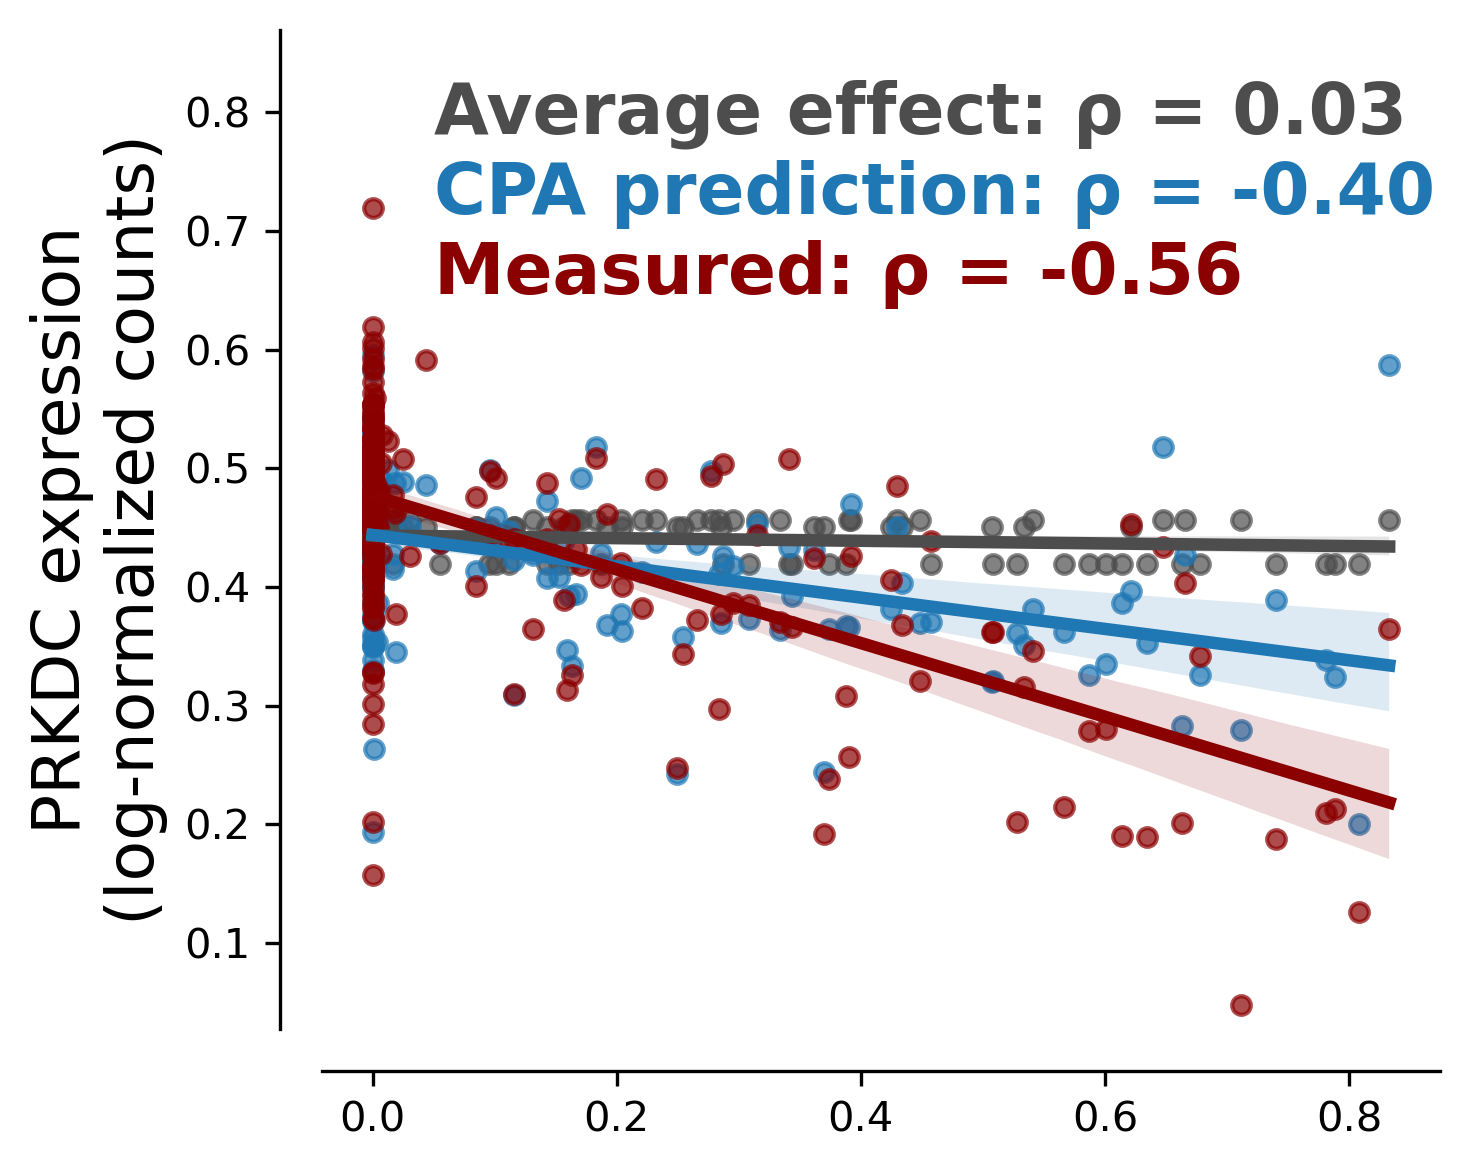

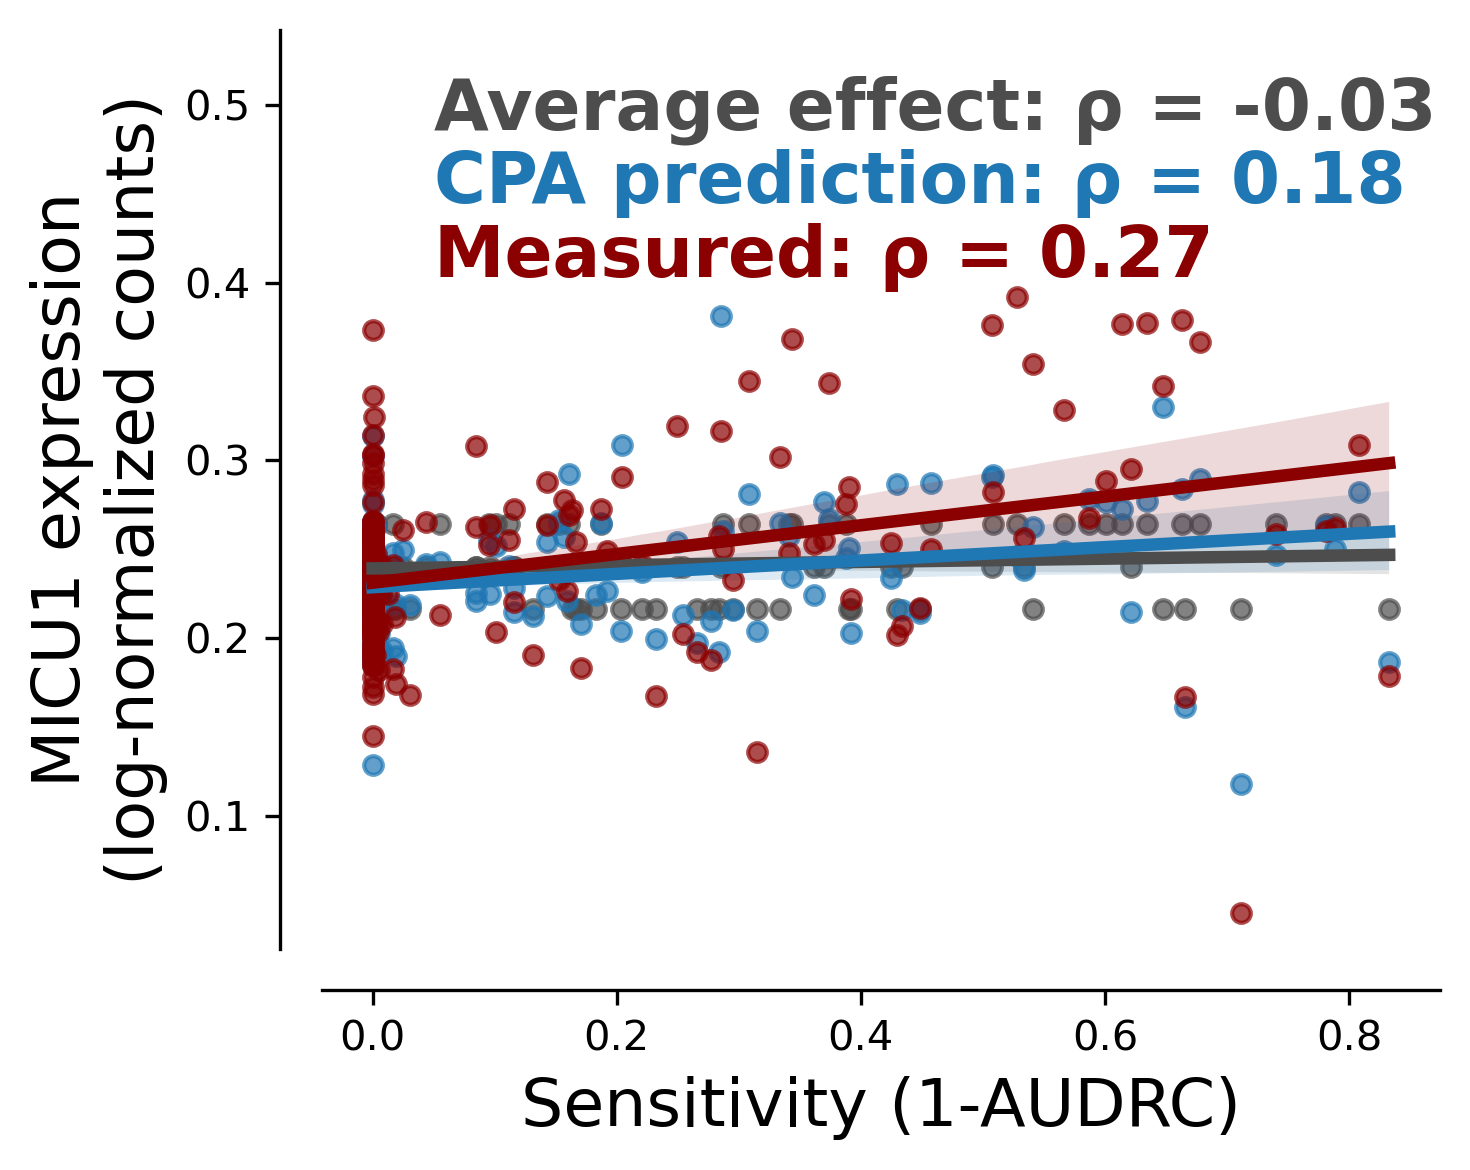

In [33]:
def plot_single_gene(gene, show_xlabel=True, panel_label=None):
    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
    # --- Compute correlations and plot ---
    datasets = [
        (baseline_with_sensitivity, 'Average effect', '#4d4d4d'),
        (cpa_with_sensitivity, 'CPA prediction', '#1f77b4'),
        (observations_with_sensitivity, 'Measured', '#8B0000'),
    ]

    # Store correlation results to annotate later
    text_y = 0.95  # starting vertical position for text
    for df, label, color in datasets:
        r, p = spearmanr(df['sensitivity'], df[gene])
        sns.regplot(
            data=df,
            x='sensitivity', y=gene,
            label=f"{label}",
            color=color,
            scatter_kws={'s': 20, 'alpha': 0.7},
            line_kws={'lw': 3},
            ax=ax
        )

        # Add correlation text (ρ and p-value)
        ax.text(
            0.1, text_y,
            f"{label}: ρ = {r:.2f}",
            transform=ax.transAxes,
            fontsize=17,
            fontdict={'color': color, 'weight': 'bold'},
            color=color,
            ha='left', va='top'
        )
        text_y -= 0.08  # move down for next label

    # --- Formatting ---
    ax.set_ylabel(f'{gene} expression\n(log-normalized counts)', fontsize=16)
    ax.set_ylim([
        observations_with_sensitivity[gene].min() - 0.02,
        observations_with_sensitivity[gene].max() + 0.15
    ])

    sns.despine(ax=ax, offset=10, trim=False)

    if show_xlabel:
        ax.set_xlabel('Sensitivity (1-AUDRC)', fontsize=16)
    else:
        ax.set_xlabel('')


    return fig, ax

genes = ['PRKDC', 'MICU1']
for gene in genes:
    show_xlabel = gene == genes[-1]  # only show xlabel for the bottom plot
    fig, ax = plot_single_gene(gene, show_xlabel=show_xlabel)
    fig.savefig(os.path.join(figures_dir, f'sciplex_{gene}_vs_sensitivity.pdf'),
                bbox_inches='tight', dpi=300)
    plt.tight_layout()
    plt.show()



# fig.savefig(os.path.join(figures_dir, 'sciplex_top3_genes_vs_sensitivity.pdf'), bbox_inches='tight', dpi=300)
